<a href="https://colab.research.google.com/github/wtryab-re/data-preprocessing/blob/main/Social_Behaviour_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports and Installations

In [247]:
#!/bin/bash
!kaggle datasets download rakeshkapilavai/extrovert-vs-introvert-behavior-data

Dataset URL: https://www.kaggle.com/datasets/rakeshkapilavai/extrovert-vs-introvert-behavior-data
License(s): CC-BY-SA-4.0
extrovert-vs-introvert-behavior-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [248]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn fg-data-profiling

In [249]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from data_profiling import ProfileReport
from zipfile import ZipFile

In [250]:
pd.set_option('display.max_columns', None)
sns.set_style("darkgrid")


#Dataset Import and Unzip

In [251]:
datafile = ZipFile("/content/extrovert-vs-introvert-behavior-data.zip", "r")
datafile.extractall()
datafile.close()

In [252]:
og_df = pd.read_csv("/content/personality_dataset.csv")
og_df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [253]:
df = og_df.copy()

#Data Overview and EDA

In [254]:
df.shape

(2900, 8)

In [255]:
df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')

In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [257]:
df.dtypes

,0
Time_spent_Alone,float64
Stage_fear,object
Social_event_attendance,float64
Going_outside,float64
Drained_after_socializing,object
Friends_circle_size,float64
Post_frequency,float64
Personality,object


In [258]:
df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


In [294]:
data_EDA_report = ProfileReport(df)
data_EDA_report.to_file("data_EDA_report.html")

#Data Quality Checks

##Check Missing Values

In [260]:
df.isna().sum()

,0
Time_spent_Alone,63
Stage_fear,73
Social_event_attendance,62
Going_outside,66
Drained_after_socializing,52
Friends_circle_size,77
Post_frequency,65
Personality,0


##Duplicates check

In [261]:
df.duplicated().sum()

np.int64(388)

##Constant and Quasi Constant columns check

In [262]:
id_like_cols = []
constant_cols = []
quasi_constant_cols = []


for col in df.columns:
  if df[col].nunique() == 1:
    constant_cols.append(col)
  elif df[col].value_counts(normalize = True).max() > 0.9:
    quasi_constant_cols.append(col)
  elif df[col].value_counts().shape[0]/df.shape[0] >0.9:
    id_like_cols.append(col)


print(f"ID-Like Columns: {id_like_cols}")
print(f"Constant Columns: {constant_cols}")
print(f"Quasi Constant Columns: {quasi_constant_cols}")

ID-Like Columns: []
Constant Columns: []
Quasi Constant Columns: []


##High Missing Values Check

In [263]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percentage = (df.isna().mean()*100).sort_values(ascending=False)

missing_df = pd.DataFrame({"missing_count":missing_count,"missing_percentage":missing_percentage})
missing_df[missing_df["missing_count"]>0]

,missing_count,missing_percentage
Friends_circle_size,77,2.655172
Stage_fear,73,2.517241
Going_outside,66,2.275862
Post_frequency,65,2.241379
Time_spent_Alone,63,2.172414
Social_event_attendance,62,2.137931
Drained_after_socializing,52,1.793103


##High Zero Check

In [264]:
number_cols = df.select_dtypes(include=np.number).columns
(df[number_cols] == 0 ).sum()

,0
Time_spent_Alone,369
Social_event_attendance,378
Going_outside,498
Friends_circle_size,106
Post_frequency,451


#Basic Handling

##Remove String Inconsistencies

In [265]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns

Index(['time_spent_alone', 'stage_fear', 'social_event_attendance',
       'going_outside', 'drained_after_socializing', 'friends_circle_size',
       'post_frequency', 'personality'],
      dtype='object')

##Dropping duplicates

In [266]:
df.duplicated().sum()

np.int64(388)

In [267]:
#In this case I'm dropping duplicates

In [268]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

##Encode the Target

In [269]:
target = "personality"

In [270]:
df[target] = df[target].map({"Introvert":0, "Extrovert":1})
df.head()

,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality
0,4.0,No,4.0,6.0,No,13.0,5.0,1
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,0
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,0
3,0.0,No,6.0,7.0,No,14.0,8.0,1
4,3.0,No,9.0,4.0,No,8.0,5.0,1


#Train Test Split

In [271]:
X = df.drop("personality", axis=1)
y = df["personality"]

X.shape, y.shape

((2512, 7), (2512,))

In [272]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1758, 7), (754, 7), (1758,), (754,))

#Cat and Num Cols

In [273]:
df.head()

,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality
0,4.0,No,4.0,6.0,No,13.0,5.0,1
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,0
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,0
3,0.0,No,6.0,7.0,No,14.0,8.0,1
4,3.0,No,9.0,4.0,No,8.0,5.0,1


  Features
  
    - Time_spent_Alone: Hours spent alone daily (0–11).
    - Stage_fear: Presence of stage fright (Yes/No).
    - Social_event_attendance: Frequency of social events (0–10).
    - Going_outside: Frequency of going outside (0–7).
    - Drained_after_socializing: Feeling drained after socializing (Yes/No).
    - Friends_circle_size: Number of close friends (0–15).
    - Post_frequency: Social media post frequency (0–10).
    - Personality: Target variable (Extrovert/Introvert).*

In [274]:
column_info = {
    "time_spent_alone": {
        "data type": "number",
        "type": "discrete",
        "action": "none"
    },
    "stage_fear": {
        "data type": "category",
        "type": "binary",
        "action": "label encoding"
    },
    "social_event_attendance": {
        "data type": "category",
        "type": "nominal",
        "action": "already encoded"}
    ,
    "going_outside": {
        "data type": "category",
        "type": "nominal",
        "action": "already encoded"
    },
    "drained_after_socializing": {
        "data type": "category",
        "type": "binary",
        "action": "label encoding"
    },
    "friends_circle_size": {
        "data type": "number",
        "type": "discrete",
        "action": "none"
    },
    "post_frequency": {
        "data type": "category",
        "type": "nominal",
        "action": "already encoded"
    }
}

data_info = pd.DataFrame(column_info).T
data_info

,data type,type,action
time_spent_alone,number,discrete,none
stage_fear,category,binary,label encoding
social_event_attendance,category,nominal,already encoded
going_outside,category,nominal,already encoded
drained_after_socializing,category,binary,label encoding
friends_circle_size,number,discrete,none
post_frequency,category,nominal,already encoded


In [275]:
num_cols = ["time_spent_alone","friends_circle_size"]
cat_cols = list(filter(lambda x: x not in num_cols and x !=target, df.columns))

num_cols,cat_cols

(['time_spent_alone', 'friends_circle_size'],
 ['stage_fear',
  'social_event_attendance',
  'going_outside',
  'drained_after_socializing',
  'post_frequency'])

#Handle Missing Values

In [276]:
X_train.isna().sum()

,0
time_spent_alone,42
stage_fear,58
social_event_attendance,39
going_outside,43
drained_after_socializing,30
friends_circle_size,56
post_frequency,50


In [277]:
imputer = SimpleImputer(strategy="median")
X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

X_train[num_cols].isna().sum()

,0
time_spent_alone,0
friends_circle_size,0


In [278]:
imputer = SimpleImputer(strategy = "most_frequent")
X_train[cat_cols] = imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = imputer.transform(X_test[cat_cols])

X_train[cat_cols].isna().sum()

,0
stage_fear,0
social_event_attendance,0
going_outside,0
drained_after_socializing,0
post_frequency,0


#Outlier Detection and Treatment

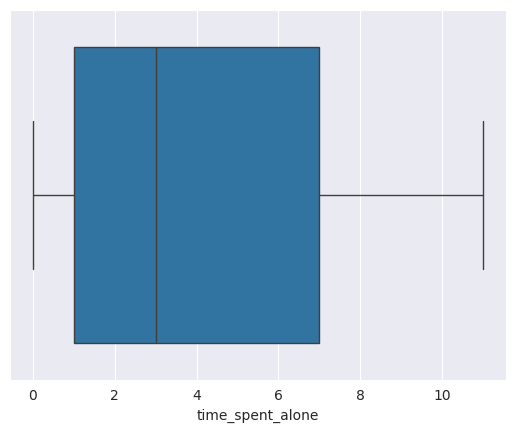

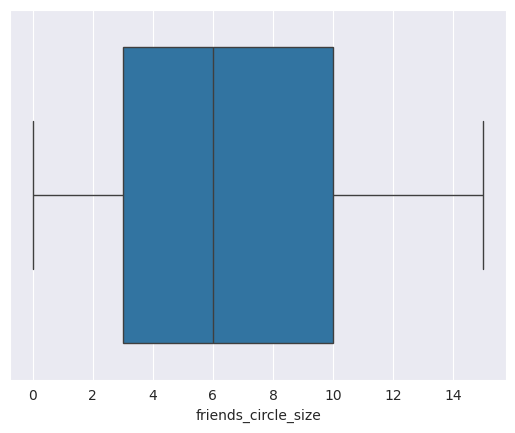

In [279]:
for col in num_cols:
  sns.boxplot(x = X_train[col])
  plt.show()
  print()

###oop no outliers surprisingly okay not that surprising because discrete

#Encoding

In [280]:
cat_cols

['stage_fear',
 'social_event_attendance',
 'going_outside',
 'drained_after_socializing',
 'post_frequency']

In [281]:
data_info

,data type,type,action
time_spent_alone,number,discrete,none
stage_fear,category,binary,label encoding
social_event_attendance,category,nominal,already encoded
going_outside,category,nominal,already encoded
drained_after_socializing,category,binary,label encoding
friends_circle_size,number,discrete,none
post_frequency,category,nominal,already encoded


In [282]:
cat_cols_for_encoding = ["stage_fear", "drained_after_socializing"]

In [283]:
label_encoders = {}

In [284]:
le = LabelEncoder()
for col in cat_cols_for_encoding:
  X_train[col] =le.fit_transform(X_train[col])
  X_test[col] = le.transform(X_test[col])
  label_encoders[col] = le

label_encoders

{'stage_fear': LabelEncoder(), 'drained_after_socializing': LabelEncoder()}

#Handle Imbalanced Data

In [285]:
y_train.value_counts(normalize=True)

,proportion
personality,
1,0.564278
0,0.435722


In [286]:
over_sampler = RandomOverSampler()

In [287]:
X_train_balanced, y_train_balanced = over_sampler.fit_resample(X_train,y_train)
X_test_balanced, y_test_balanced = over_sampler.fit_resample(X_test,y_test)

X_train.shape, X_train_balanced.shape, y_train.shape, y_train_balanced.shape

((1758, 7), (1984, 7), (1758,), (1984,))

#Standardization

In [288]:
scaler = StandardScaler()
X_train_balanced[num_cols] = scaler.fit_transform(X_train_balanced[num_cols])
X_test_balanced[num_cols] = scaler.transform(X_test_balanced[num_cols])

X_train_balanced.describe()

,time_spent_alone,stage_fear,drained_after_socializing,friends_circle_size
count,1.984000e+03,1984.000000,1984.000000,1.984000e+03
mean,-2.865092e-17,0.495968,0.500504,-1.432546e-17
std,1.000252e+00,0.500110,0.500126,1.000252e+00
min,-1.316996e+00,0.000000,0.000000,-1.449535e+00
25%,-7.467383e-01,0.000000,0.000000,-7.375080e-01
50%,-1.764809e-01,0.000000,1.000000,-2.628232e-01
75%,9.640340e-01,1.000000,1.000000,6.865464e-01
max,1.819420e+00,1.000000,1.000000,2.110601e+00


In [290]:
df_train_cleaned = pd.concat([X_train_balanced,y_train_balanced], axis = 1)
df_train_cleaned

,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality
0,0.108648,1,1.0,0.0,1,-0.262823,2.0,0
1,-0.461610,0,9.0,6.0,0,1.635916,8.0,1
2,-0.746738,0,8.0,6.0,0,0.923889,9.0,0
3,0.678905,1,0.0,2.0,1,-0.262823,1.0,0
4,-0.176481,0,10.0,4.0,0,0.686546,10.0,1
...,...,...,...,...,...,...,...,...
1979,1.249163,0,2.0,0.0,1,-0.500166,2.0,0
1980,-0.176481,1,0.0,1.0,0,-0.025481,0.0,0
1981,1.249163,1,2.0,0.0,1,-0.500166,0.0,0
1982,1.534291,1,3.0,0.0,1,-0.737508,1.0,0


In [292]:
df_test_cleaned = pd.concat([X_test_balanced,y_test_balanced], axis = 1)
df_test_cleaned

,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality
0,-0.461610,0,4.0,5.0,0,1.161231,2.0,1
1,0.108648,1,0.0,2.0,1,-0.262823,2.0,0
2,0.678905,1,2.0,2.0,1,-0.500166,1.0,0
3,-1.031867,0,4.0,4.0,0,0.211862,6.0,1
4,0.964034,1,0.0,0.0,1,-0.262823,0.0,0
...,...,...,...,...,...,...,...,...
845,1.534291,1,3.0,0.0,1,-0.737508,0.0,0
846,0.393777,1,2.0,1.0,1,-1.449535,1.0,0
847,0.964034,1,2.0,1.0,1,-0.737508,2.0,0
848,1.534291,1,3.0,0.0,1,-0.737508,0.0,0


#SAVE

In [293]:
df_test_cleaned.to_csv("test_cleaned.csv", index=False)
df_train_cleaned.to_csv("train_cleaned.csv", index=False)